N=round( 1.9 𝝿 / 1 ) = 6


Row,Stitch count
0,10
1,12
2,16
3,22
4,28
5,32
6,34


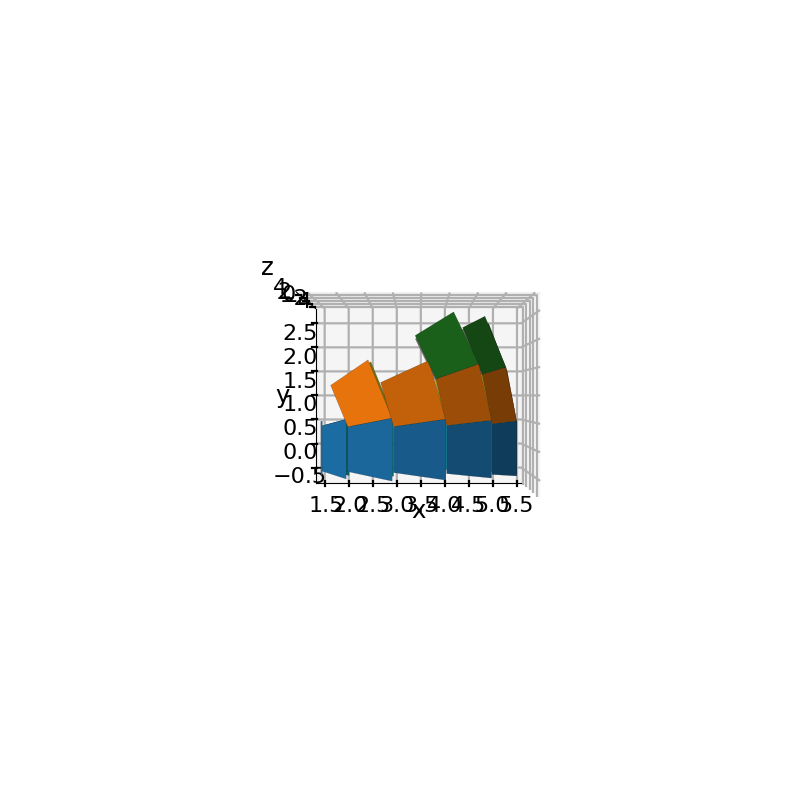

In [7]:
from tabulate import tabulate
import numpy as np
from mpl_toolkits import mplot3d
import matplotlib.pyplot as plt
from matplotlib.colors import TABLEAU_COLORS, same_color
prop_cycle = plt.rcParams['axes.prop_cycle']
colors = prop_cycle.by_key()['color']

%matplotlib ipympl

plt.style.use('seaborn-v0_8-poster')

# Major & minor radii
R = 3.5
r = 1.9
# Stitch dimensions
w = 1
h = 1
# Row count
N = round(r*np.pi/h)

print('N=round(',r,'𝝿','/',h,')','=',N)

# Stitch count
st_count = [0]*(N+1)
row = [0]*(N+1)
for n in range(N+1):
    st_count[n]=round(2*np.pi*(R-r*np.cos(n*np.pi/int(N)))/w)
    row[n] = n #"Row "+str(n)+": "+str(st_count[n])+" st."


# Stitch count table
table = np.transpose([row, st_count])
pattern = tabulate(table,headers=["Row","Stitch count"],tablefmt="html")
display(pattern)

# Pattern model
fig = plt.figure(figsize = (8,8))
ax = plt.axes(projection='3d')
ax.grid()
for n in range(int(N)+1):
    K = round(st_count[n]/st_count[0])
    for k in range(K):
        theta = n*np.pi/N
        phi = k*2*np.pi/st_count[n] # < phi1
        u = np.linspace((n-.5)*np.pi/N, (n+.5)*np.pi/N, 2)
        v = np.linspace((k-.5)*2*np.pi/st_count[n], (k+.5)*2*np.pi/st_count[n], 2)
        u, v = np.meshgrid(u, v)
        x = (R-r*np.cos(u))*np.cos(v)
        y = (R-r*np.cos(u))*np.sin(v)
        z = r*np.sin(u)
        ax.plot_surface(x, y, z, color=colors[k%10], edgecolor='black', linewidth=.1)
        if n>0 and n<N:
            ax.plot_surface(x, y, -z, color=colors[9-k%10], edgecolor='black', linewidth=.1)
# Axis labels
ax.set_xlabel('x', labelpad=20)
ax.set_ylabel('y', labelpad=20)
ax.set_zlabel('z', labelpad=20)

# Axis limits
ax.set(zlim=(-R-r,R+r))

ax.set_aspect('equal')

ax.view_init(elev=90, azim=-90, roll=0)

plt.show()